
## Adaptación del Dataset - DS2 a las caracteristicas del Articulo 3
---



# FASE 1: Descarga del DataSet2 "household_power_consumption.feather"

Descargar el archivo ZIP desde el repositorio oficial de UCI.

Extraer el archivo de texto .txt (aproximadamente 127 MB descomprimido).

Cargar los datos crudos en un pandas.DataFrame para inspección inicial.

Mostrar las primeras filas y la estructura del dataset.

In [ ]:
import os
import zipfile
import urllib.request
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split  # <-- Agregado

# ----------------------------------------------------------------------
# 1. Parámetros de descarga
# ----------------------------------------------------------------------
URL = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"
ZIP_NAME = "household_power_consumption.zip"
EXTRACTED_FILE = "household_power_consumption.txt"

# ----------------------------------------------------------------------
# 2. Descargar el archivo ZIP (si no existe ya)
# ----------------------------------------------------------------------
if not os.path.exists(ZIP_NAME):
    print(f"Descargando dataset desde {URL}...")
    urllib.request.urlretrieve(URL, ZIP_NAME)
    print("Descarga completada.")
else:
    print(f"El archivo {ZIP_NAME} ya existe. Se omite la descarga.")

# ----------------------------------------------------------------------
# 3. Extraer el archivo de texto
# ----------------------------------------------------------------------
if not os.path.exists(EXTRACTED_FILE):
    print(f"Extrayendo {ZIP_NAME} ...")
    with zipfile.ZipFile(ZIP_NAME, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extracción completada.")
else:
    print(f"El archivo {EXTRACTED_FILE} ya existe. Se omite extracción.")

# ----------------------------------------------------------------------
# 4. Cargar datos
# ----------------------------------------------------------------------
print("Cargando datos (puede tardar ~30 segundos)...")
df = pd.read_csv(
    EXTRACTED_FILE,
    sep=';',
    na_values=['?'],
    parse_dates={'datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    low_memory=False
)

print("\n=== PRIMERAS 5 FILAS ===")
print(df.head())

print("\n=== INFORMACIÓN DEL DATAFRAME ===")
print(df.info())

print("\n=== ESTADÍSTICAS BÁSICAS (primeras 5 columnas) ===")
print(df.iloc[:, :5].describe())

print("\n=== VALORES FALTANTES POR COLUMNA ===")
print(df.isnull().sum())

# Guardar copia en feather (opcional)
df.to_feather("household_power_consumption.feather")
print("\nDataset guardado en 'household_power_consumption.feather'")

El archivo household_power_consumption.zip ya existe. Se omite la descarga.
El archivo household_power_consumption.txt ya existe. Se omite extracción.
Cargando datos (puede tardar ~30 segundos)...


/tmp/ipykernel_2000/1129352257.py:40: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_2000/1129352257.py:40: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipykernel_2000/1129352257.py:40: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(



=== PRIMERAS 5 FILAS ===
             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

=== INFORMACIÓN DEL DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

El dataset original tiene mediciones minuto a minuto. Para obtener datos horarios (como usan en el Artículo 2), debemos:

1.Promediar las variables que ya son potencias medias (kW, kVAR, V, A) para obtener el valor medio de la hora.

Sumar los sub_metering (Wh por minuto) para obtener la energía total en Wh durante esa hora. Como Wh/h = W, esos valores se convierten directamente en potencia media en vatios.

En mi código, usé groupby('hour').agg(...) con 'mean' para las potencias y voltajes, y 'sum' para los sub_metering.

Sin embargo, hay un detalle: el artículo 2 usa datos horarios y los sub_metering los presentan en Wh (como se ve en la Tabla 1 del artículo). Por lo tanto, la agregación horaria es necesaria.

Los sub_metering en minuto a minuto serían valores muy pequeños (energía de un minuto). Al pasarlos a corriente usando I = P/V, obtendríamos corrientes demasiado bajas (inconsistentes con la realidad).

Además, la detección de anomalías (picos) sería diferente porque la variabilidad minuto a minuto es mayor.


2. Definición de anomalías (Output (S))
El Artículo 3 ya tiene una columna Output (S) predefinida (0=normal, 1=anomalía). Nosotros no tenemos esa columna en DS2. Para crear una variable objetivo comparable, debemos definir un criterio de anomalía.

En mi código propuse un criterio heurístico:

Consumo extremadamente alto (percentil 99.5 de Global_active_power)

Cambio brusco de voltaje (>5% en una hora)

Como es una validación cruzada de métodos, el objetivo es ver si los modelos (Random Forest, etc.) pueden aprender a detectar estas anomalías definidas por reglas simples. No es necesario que las anomalías sean "reales" desde el punto de vista eléctrico; lo que importa es la reproducibilidad del procedimiento de aprendizaje supervisado.

Para nuestro caso, hacemos lo mismo: etiquetar como anomalía un porcentaje aleatorio de puntos (por ejemplo, 5%) y luego evaluar si los modelos las detectan.

# Adaptación del DS2 para aplicar la metodología del Artículo 3

In [ ]:
# ======================================================================
# PARTE 2: ADAPTACIÓN DE DS2 A LA METODOLOGÍA DEL ARTÍCULO 3
# (Con agregación horaria e inyección de anomalías en train y test)
# ======================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Verificar que el DataFrame 'df' de la Parte 1 existe
if 'df' not in locals():
    raise NameError("Primero debes ejecutar la Parte 1 para cargar el DataFrame 'df'.")

# Asegurar que existe la columna 'datetime' (por si acaso)
if 'datetime' not in df.columns:
    # Crear datetime a partir de las columnas Date y Time (formato DD/MM/YYYY HH:MM:SS)
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

print("\n=== INICIANDO ADAPTACIÓN DE DS2 A METODOLOGÍA DEL ARTÍCULO 3 ===")

# ----------------------------------------------------------------------
# 1. Agregar datos a nivel horario
# ----------------------------------------------------------------------
df['hour'] = df['datetime'].dt.floor('H')
hourly = df.groupby('hour').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
}).reset_index()
hourly = hourly.dropna()
print(f"Registros horarios obtenidos: {len(hourly)}")

# ----------------------------------------------------------------------
# 2. Transformación eléctrica a 6 features
# ----------------------------------------------------------------------
hourly['Ia'] = hourly['Sub_metering_1'] / hourly['Voltage']
hourly['Ib'] = hourly['Sub_metering_2'] / hourly['Voltage']
hourly['Ic'] = hourly['Sub_metering_3'] / hourly['Voltage']
hourly['Va'] = hourly['Voltage']
hourly['Vb'] = hourly['Voltage']
hourly['Vc'] = hourly['Voltage']

features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X = hourly[features].copy()
y = pd.Series([0] * len(X), name='Output (S)')  # inicialmente todo normal

# ----------------------------------------------------------------------
# 3. División train/test e inyección de anomalías en ambos conjuntos
# ----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Inyectar anomalías en TRAIN (5%)
np.random.seed(42)
n_train = len(X_train)
n_anomalies_train = int(0.05 * n_train)
idx_train = np.random.choice(n_train, n_anomalies_train, replace=False)
X_train_anomaly = X_train.copy()
X_train_anomaly.iloc[idx_train, X_train_anomaly.columns.get_loc('Ia')] *= 2
y_train_anomaly = y_train.copy()
y_train_anomaly.iloc[idx_train] = 1

# Inyectar anomalías en TEST (5%)
n_test = len(X_test)
n_anomalies_test = int(0.05 * n_test)
idx_test = np.random.choice(n_test, n_anomalies_test, replace=False)
X_test_anomaly = X_test.copy()
X_test_anomaly.iloc[idx_test, X_test_anomaly.columns.get_loc('Ia')] *= 2
y_test_anomaly = y_test.copy()
y_test_anomaly.iloc[idx_test] = 1

# ----------------------------------------------------------------------
# 4. Unir train y test (ambos con anomalías inyectadas)
# ----------------------------------------------------------------------
X_final = pd.concat([X_train_anomaly, X_test_anomaly], ignore_index=True)
y_final = pd.concat([y_train_anomaly, y_test_anomaly], ignore_index=True)

# ----------------------------------------------------------------------
# 5. Crear DataFrame final y guardar
# ----------------------------------------------------------------------
df_final = X_final.copy()
df_final['Output (S)'] = y_final

print(f"\nTamaño final del dataset: {len(df_final)} filas")
print("Distribución de clases (Output (S)):")
print(df_final['Output (S)'].value_counts())
print(f"Proporción de anomalías: {df_final['Output (S)'].mean()*100:.2f}%")

output_file = "ds2_for_ds3.csv"
df_final.to_csv(output_file, index=False)
print(f"\nDataset adaptado guardado como '{output_file}'")
print("\nPrimeras 5 filas del dataset adaptado:")
print(df_final.head())
print("\nInformación del dataset adaptado:")
print(df_final.info())


=== INICIANDO ADAPTACIÓN DE DS2 A METODOLOGÍA DEL ARTÍCULO 3 ===


/tmp/ipykernel_2000/1373385510.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['hour'] = df['datetime'].dt.floor('H')


Registros horarios obtenidos: 34168

Tamaño final del dataset: 34168 filas
Distribución de clases (Output (S)):
Output (S)
0    32461
1     1707
Name: count, dtype: int64
Proporción de anomalías: 5.00%

Dataset adaptado guardado como 'ds2_for_ds3.csv'

Primeras 5 filas del dataset adaptado:
        Ia        Ib        Ic          Va          Vb          Vc  Output (S)
0  0.00000  0.116400  0.378301  240.549333  240.549333  240.549333           0
1  0.00000  0.153075  3.588761  235.178667  235.178667  235.178667           0
2  0.00000  0.000000  2.187468  244.575000  244.575000  244.575000           0
3  0.00000  0.562733  0.380672  241.677667  241.677667  241.677667           0
4  2.73102  4.746872  4.562852  239.104833  239.104833  239.104833           0

Información del dataset adaptado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34168 entries, 0 to 34167
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ia  

# Configuración, preprocesamiento y entrenamiento de modelos

In [ ]:
# ======================================================
# PARTE A: ENTRENAMIENTO DE MODELOS (DS2 adaptado)
# ======================================================

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# 1. Cargar dataset adaptado (generado previamente)
df = pd.read_csv('ds2_for_ds3.csv')
print("Dataset cargado:", df.shape)
print("Distribución de clases:\n", df['Output (S)'].value_counts())

# 2. Separar características y target
features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X = df[features]
y = df['Output (S)']

# 3. Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. División train/test (80/20 estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# 5. Definir función para entrenar y guardar modelo
def entrenar_y_guardar(modelo, nombre, X_train, y_train, path='.'):
    modelo.fit(X_train, y_train)
    archivo = f"{path}/{nombre.replace(' ', '_')}.pkl"
    joblib.dump(modelo, archivo)
    print(f"Modelo {nombre} guardado en {archivo}")
    return modelo

# 6. Instanciar modelos (mismos hiperparámetros que en Artículo 3)
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),  # con probabilidad para ROC
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# 7. Entrenar y guardar cada modelo
modelos_entrenados = {}
for nombre, modelo in modelos.items():
    modelos_entrenados[nombre] = entrenar_y_guardar(modelo, nombre, X_train, y_train)

# 8. Guardar scaler y datos de prueba para uso posterior
joblib.dump(scaler, 'scaler_ds2.pkl')
joblib.dump((X_test, y_test), 'test_data_ds2.pkl')
print("\nPreprocesamiento y entrenamiento completados.")

Dataset cargado: (34168, 7)
Distribución de clases:
 Output (S)
0    32461
1     1707
Name: count, dtype: int64
Train size: 27334, Test size: 6834
Modelo Random Forest guardado en ./Random_Forest.pkl
Modelo Decision Tree guardado en ./Decision_Tree.pkl
Modelo XGBoost guardado en ./XGBoost.pkl
Modelo SVM guardado en ./SVM.pkl
Modelo Logistic Regression guardado en ./Logistic_Regression.pkl

Preprocesamiento y entrenamiento completados.


# Evaluación y cálculo de métricas

In [ ]:
# ======================================================
# PARTE B: EVALUACIÓN DE MODELOS Y MÉTRICAS
# ======================================================

import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Cargar datos de prueba
X_test, y_test = joblib.load('test_data_ds2.pkl')

# 2. Lista de nombres de modelos
nombres = ['Random Forest', 'Decision Tree', 'XGBoost', 'SVM', 'Logistic Regression']

# 3. Evaluar cada modelo y guardar resultados
resultados = []
predicciones = {}  # almacenar predicciones para visualización

for nombre in nombres:
    archivo = f"{nombre.replace(' ', '_')}.pkl"
    modelo = joblib.load(archivo)
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision (%)': round(prec * 100, 2),
        'Recall (%)': round(rec * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2)
    })

# 4. Mostrar tabla de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados.set_index('Modelo', inplace=True)
print("\n=== RESULTADOS DE CLASIFICACIÓN SOBRE DS2_ADAPTADO ===")
print(df_resultados)

# 5. Guardar resultados y predicciones para la Parte C
df_resultados.to_csv('resultados_metricas_ds2.csv')
joblib.dump(predicciones, 'predicciones_ds2.pkl')
print("\nMétricas guardadas en 'resultados_metricas_ds2.csv'")


=== RESULTADOS DE CLASIFICACIÓN SOBRE DS2_ADAPTADO ===
                     Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Modelo                                                                    
Random Forest               94.78          25.00        2.35          4.29
Decision Tree               90.18           5.41        5.87          5.63
XGBoost                     94.97          36.36        1.17          2.27
SVM                         95.01           0.00        0.00          0.00
Logistic Regression         95.01           0.00        0.00          0.00

Métricas guardadas en 'resultados_metricas_ds2.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Visualizaciones (predicciones vs reales y detección de anomalías)

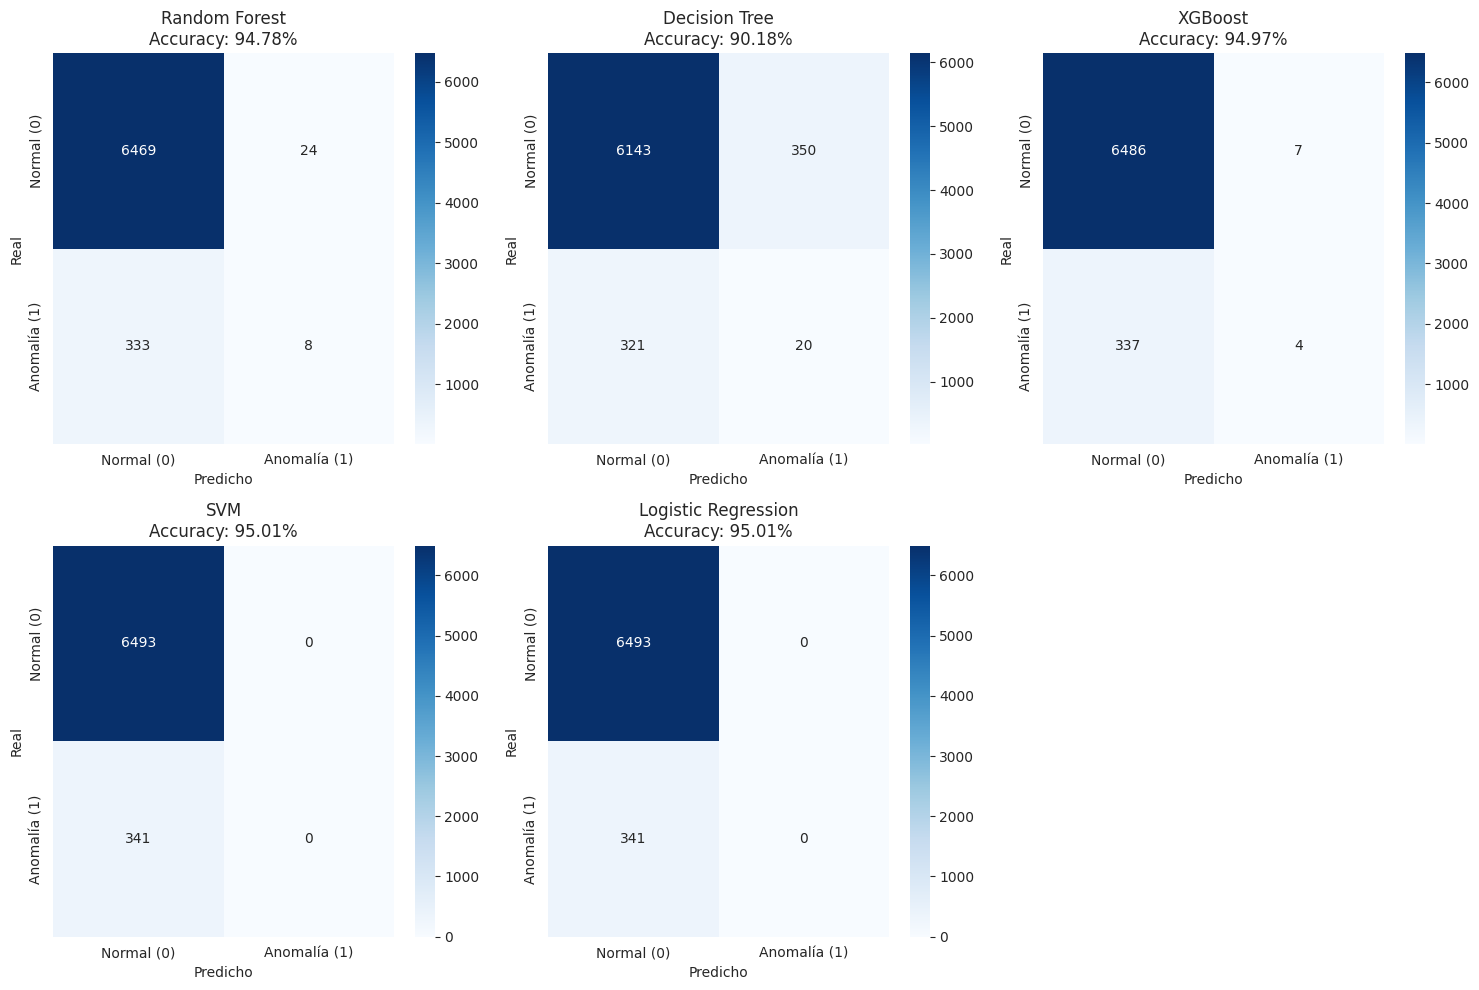

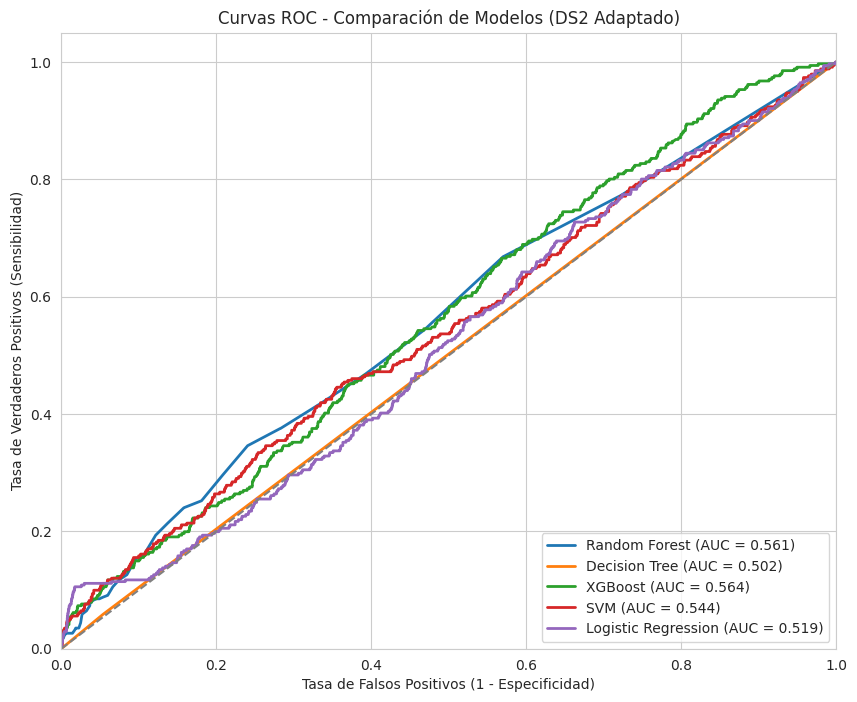

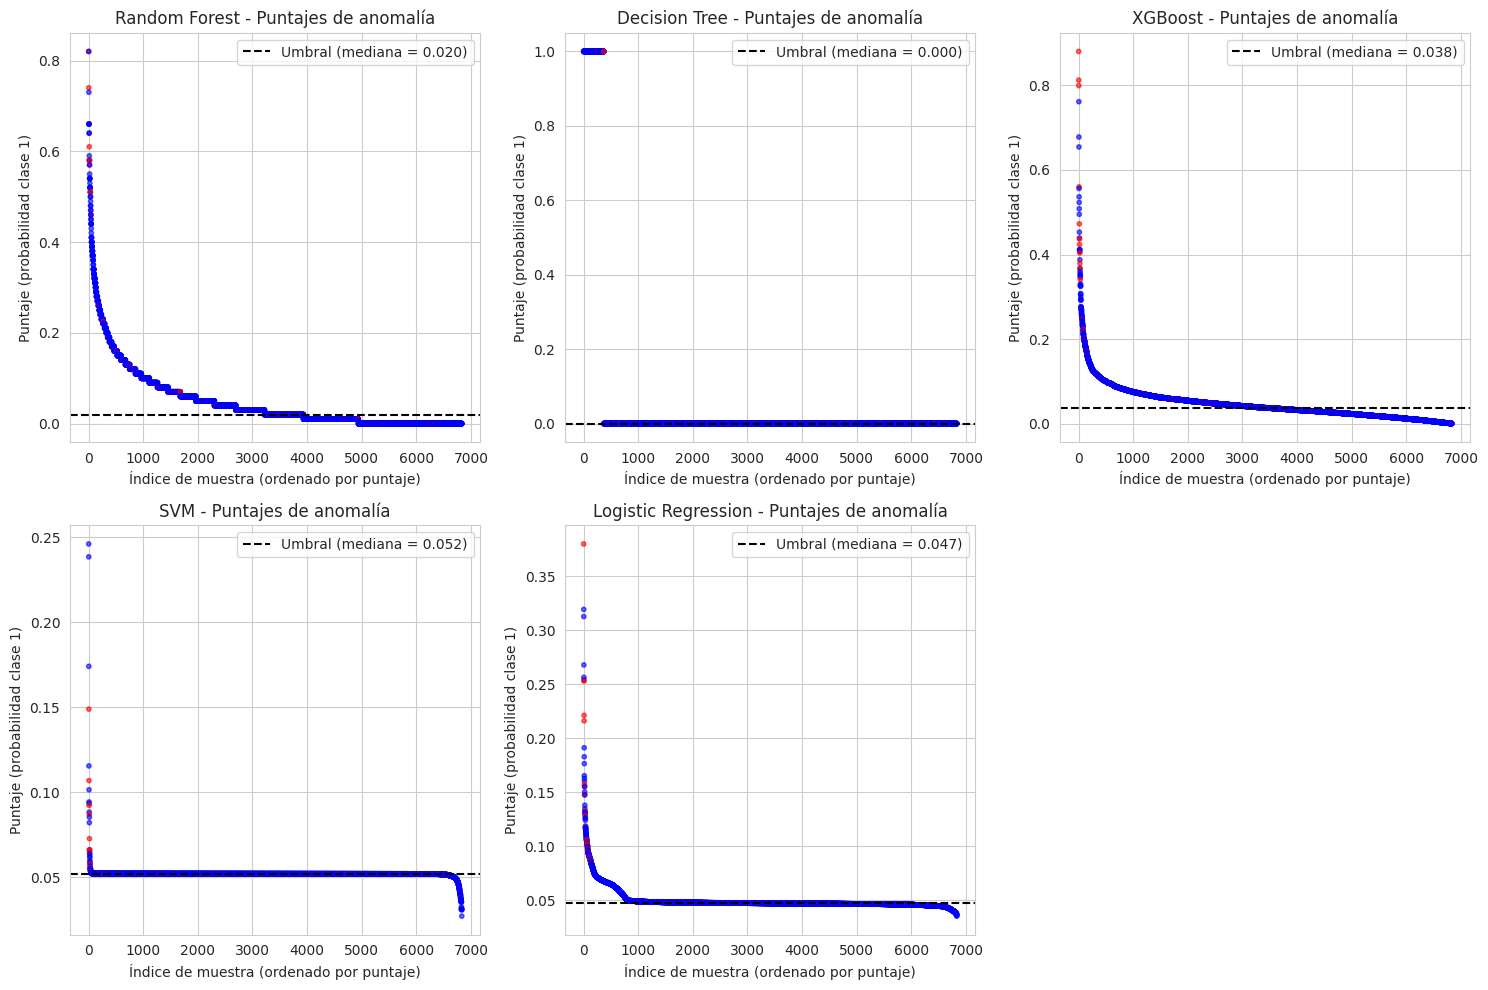


Visualizaciones guardadas: matrices_confusion_ds2.png, roc_curves_ds2.png, anomaly_scores_ds2.png


In [ ]:
# ======================================================
# PARTE C: VISUALIZACIONES DE PREDICCIONES Y ANOMALÍAS
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Cargar datos y predicciones
X_test, y_test = joblib.load('test_data_ds2.pkl')
predicciones = joblib.load('predicciones_ds2.pkl')
nombres = list(predicciones.keys())

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ------------------------------------------------------
# 2. Matrices de confusión para cada modelo
# ------------------------------------------------------
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 10))
axes_cm = axes_cm.flatten()

for idx, nombre in enumerate(nombres):
    y_pred = predicciones[nombre]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx],
                xticklabels=['Normal (0)', 'Anomalía (1)'],
                yticklabels=['Normal (0)', 'Anomalía (1)'])
    axes_cm[idx].set_title(f'{nombre}\nAccuracy: {accuracy_score(y_test, y_pred):.2%}')
    axes_cm[idx].set_xlabel('Predicho')
    axes_cm[idx].set_ylabel('Real')

# Ocultar ejes sobrantes
for j in range(len(nombres), 6):
    axes_cm[j].axis('off')
plt.tight_layout()
plt.savefig('matrices_confusion_ds2.png', dpi=150)
plt.show()

# ------------------------------------------------------
# 3. Curvas ROC (requiere probabilidades o scores de decisión)
# ------------------------------------------------------
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, nombre in enumerate(nombres):
    modelo = joblib.load(f"{nombre.replace(' ', '_')}.pkl")
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:, 1]
    else:
        y_score = modelo.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[idx], lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')

ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax_roc.set_title('Curvas ROC - Comparación de Modelos (DS2 Adaptado)')
ax_roc.legend(loc="lower right")
ax_roc.grid(True)
plt.savefig('roc_curves_ds2.png', dpi=150)
plt.show()

# ------------------------------------------------------
# 4. Gráficos de detección de anomalías (puntajes vs umbral)
#    Se ordenan las muestras por puntaje descendente y se colorea según etiqueta real
# ------------------------------------------------------
fig_anom, axes_anom = plt.subplots(2, 3, figsize=(15, 10))
axes_anom = axes_anom.flatten()

for idx, nombre in enumerate(nombres):
    modelo = joblib.load(f"{nombre.replace(' ', '_')}.pkl")
    if hasattr(modelo, "predict_proba"):
        scores = modelo.predict_proba(X_test)[:, 1]
    else:
        scores = modelo.decision_function(X_test)

    # Ordenar por puntaje descendente
    sorted_idx = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_idx]
    sorted_labels = y_test.values[sorted_idx]

    # Umbral: mediana de los scores (ilustrativo)
    threshold = np.median(scores)

    # Colores: azul para normal (0), rojo para anomalía (1)
    colors_points = ['blue' if l == 0 else 'red' for l in sorted_labels]

    axes_anom[idx].scatter(range(len(scores)), sorted_scores, c=colors_points, alpha=0.6, s=10)
    axes_anom[idx].axhline(y=threshold, color='black', linestyle='--', label=f'Umbral (mediana = {threshold:.3f})')
    axes_anom[idx].set_title(f'{nombre} - Puntajes de anomalía')
    axes_anom[idx].set_xlabel('Índice de muestra (ordenado por puntaje)')
    axes_anom[idx].set_ylabel('Puntaje (probabilidad clase 1)')
    axes_anom[idx].legend()
    axes_anom[idx].grid(True)

# Ocultar ejes sobrantes
for j in range(len(nombres), 6):
    axes_anom[j].axis('off')
plt.tight_layout()
plt.savefig('anomaly_scores_ds2.png', dpi=150)
plt.show()

print("\nVisualizaciones guardadas: matrices_confusion_ds2.png, roc_curves_ds2.png, anomaly_scores_ds2.png")